# House Price Prediction using Machine Learning


In [318]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [319]:
df = pd.read_csv("Indian_House_Price.csv")

In [320]:
df.head()

,City,Locality,BHK,Area_sqft,Bathrooms,Total_Floors,Floor_Number,Parking_Spaces,Balcony,Property_Age,Furnishing,Property_Type,Distance_to_City_Center_km,Metro_Distance_km,Nearby_Schools,Nearby_Hospitals,Amenities_Score,Security_Score,Maintenance_Cost,Price_INR
0,Mumbai,Andheri,2,1278,2.00,15,14,0.00,1.00,27,Semi-Furnished,Apartment,6.80,4.80,2.00,0,10.00,10,6133,21299000
1,Bengaluru,Electronic City,4,2319,3.00,15,9,2.00,1.00,27,Semi-Furnished,Villa,2.70,10.80,1.00,2,4.00,2,12338,20496000
2,Pune,Viman Nagar,2,1173,1.00,3,2,1.00,2.00,29,Fully-Furnished,Apartment,4.10,1.20,10.00,7,5.00,3,6449,9577000
3,Chennai,Anna Nagar,4,2148,4.00,6,3,0.00,1.00,28,Unfurnished,Apartment,4.30,1.70,6.00,1,7.00,5,12526,15947000
4,Vijayawada,Patamata,2,1341,1.00,2,1,1.00,3.00,26,Semi-Furnished,Apartment,1.50,2.30,6.00,4,10.00,5,6194,6117000


## Understanding the dataset

In [321]:
df.shape

(5025, 20)

In [322]:
df.columns

Index(['City', 'Locality', 'BHK', 'Area_sqft', 'Bathrooms', 'Total_Floors',
       'Floor_Number', 'Parking_Spaces', 'Balcony', 'Property_Age',
       'Furnishing', 'Property_Type', 'Distance_to_City_Center_km',
       'Metro_Distance_km', 'Nearby_Schools', 'Nearby_Hospitals',
       'Amenities_Score', 'Security_Score', 'Maintenance_Cost', 'Price_INR'],
      dtype='str')

In [323]:
df.dtypes

City                              str
Locality                          str
BHK                             int64
Area_sqft                       int64
Bathrooms                     float64
Total_Floors                    int64
Floor_Number                    int64
Parking_Spaces                float64
Balcony                       float64
Property_Age                    int64
Furnishing                        str
Property_Type                     str
Distance_to_City_Center_km    float64
Metro_Distance_km             float64
Nearby_Schools                float64
Nearby_Hospitals                int64
Amenities_Score               float64
Security_Score                  int64
Maintenance_Cost                int64
Price_INR                       int64
dtype: object

In [324]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   City                        5025 non-null   str    
 1   Locality                    5025 non-null   str    
 2   BHK                         5025 non-null   int64  
 3   Area_sqft                   5025 non-null   int64  
 4   Bathrooms                   5005 non-null   float64
 5   Total_Floors                5025 non-null   int64  
 6   Floor_Number                5025 non-null   int64  
 7   Parking_Spaces              5010 non-null   float64
 8   Balcony                     5010 non-null   float64
 9   Property_Age                5025 non-null   int64  
 10  Furnishing                  5005 non-null   str    
 11  Property_Type               5025 non-null   str    
 12  Distance_to_City_Center_km  5025 non-null   float64
 13  Metro_Distance_km           5010 non-null   

In [325]:
df.describe()

,BHK,Area_sqft,Bathrooms,Total_Floors,Floor_Number,Parking_Spaces,Balcony,Property_Age,Distance_to_City_Center_km,Metro_Distance_km,Nearby_Schools,Nearby_Hospitals,Amenities_Score,Security_Score,Maintenance_Cost,Price_INR
count,"5,025.00","5,025.00","5,005.00","5,025.00","5,025.00","5,010.00","5,010.00","5,025.00","5,025.00","5,010.00","5,010.00","5,025.00","5,010.00","5,025.00","5,025.00","5,025.00"
mean,2.85,"1,727.11",2.88,7.32,4.18,1.44,1.44,19.97,6.98,3.61,5.02,3.50,5.50,5.48,"6,890.97","14,403,778.31"
std,1.01,484.21,1.19,3.96,3.09,0.80,0.80,11.80,4.54,2.70,3.18,2.30,2.86,2.86,"2,853.28","6,690,763.09"
min,1.00,450.00,1.00,2.00,1.00,0.00,0.00,0.00,0.50,0.20,0.00,0.00,1.00,1.00,984.00,"1,800,000.00"
25%,2.00,"1,378.00",2.00,4.00,2.00,1.00,1.00,10.00,3.60,1.60,2.00,1.00,3.00,3.00,"4,701.00","9,865,000.00"
50%,3.00,"1,711.00",3.00,7.00,3.00,1.00,1.00,20.00,6.10,2.90,5.00,3.00,5.00,5.00,"6,483.00","13,080,000.00"
75%,4.00,"2,062.00",4.00,10.00,6.00,2.00,2.00,30.00,9.30,4.80,8.00,6.00,8.00,8.00,"8,754.00","17,279,000.00"
max,5.00,"3,373.00",6.00,15.00,15.00,3.00,3.00,40.00,25.00,15.00,10.00,7.00,10.00,10.00,"17,775.00","48,906,000.00"


# Missing Values

In [326]:
df.isnull().sum()

City                           0
Locality                       0
BHK                            0
Area_sqft                      0
Bathrooms                     20
Total_Floors                   0
Floor_Number                   0
Parking_Spaces                15
Balcony                       15
Property_Age                   0
Furnishing                    20
Property_Type                  0
Distance_to_City_Center_km     0
Metro_Distance_km             15
Nearby_Schools                15
Nearby_Hospitals               0
Amenities_Score               15
Security_Score                 0
Maintenance_Cost               0
Price_INR                      0
dtype: int64

In [327]:
df.duplicated().sum()

np.int64(21)

In [328]:
missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

Bathrooms            20
Parking_Spaces       15
Balcony              15
Furnishing           20
Metro_Distance_km    15
Nearby_Schools       15
Amenities_Score      15
dtype: int64


# Handling Missing Values

In [329]:
numeric_cols = [
    "Bathrooms",
    "Parking_Spaces",
    "Balcony",
    "Metro_Distance_km",
    "Nearby_Schools",
    "Amenities_Score"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df["Furnishing"] = df["Furnishing"].fillna(
    df["Furnishing"].mode()[0]
)

In [330]:
print(df.isnull().sum())

City                          0
Locality                      0
BHK                           0
Area_sqft                     0
Bathrooms                     0
Total_Floors                  0
Floor_Number                  0
Parking_Spaces                0
Balcony                       0
Property_Age                  0
Furnishing                    0
Property_Type                 0
Distance_to_City_Center_km    0
Metro_Distance_km             0
Nearby_Schools                0
Nearby_Hospitals              0
Amenities_Score               0
Security_Score                0
Maintenance_Cost              0
Price_INR                     0
dtype: int64


# Checking Duplicate Values

In [331]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
5020    False
5021    False
5022    False
5023    False
5024    False
Length: 5025, dtype: bool


In [332]:
print(df.duplicated().sum())

22


# Removing Duplicate Rows

In [333]:
df = df.drop_duplicates()

In [334]:
print(df.duplicated().sum())

0


In [335]:
print(df.shape)

(5003, 20)


# Save Clean Dataset

In [336]:
df.to_csv("House_Prediction_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Correlation

In [337]:
df.corr(numeric_only=True)

,BHK,Area_sqft,Bathrooms,Total_Floors,Floor_Number,Parking_Spaces,Balcony,Property_Age,Distance_to_City_Center_km,Metro_Distance_km,Nearby_Schools,Nearby_Hospitals,Amenities_Score,Security_Score,Maintenance_Cost,Price_INR
BHK,1.00,0.89,0.81,-0.01,-0.01,0.01,0.01,-0.01,-0.01,-0.00,0.01,0.01,0.00,0.01,0.61,0.56
Area_sqft,0.89,1.00,0.73,-0.01,-0.01,0.02,0.00,-0.02,-0.01,0.01,0.02,0.01,0.00,-0.00,0.68,0.61
Bathrooms,0.81,0.73,1.00,-0.01,-0.02,0.00,0.01,-0.03,-0.00,0.01,-0.00,0.00,0.01,0.01,0.50,0.45
Total_Floors,-0.01,-0.01,-0.01,1.00,0.65,-0.02,0.02,-0.01,0.00,0.01,0.00,-0.01,-0.02,-0.01,-0.01,-0.01
Floor_Number,-0.01,-0.01,-0.02,0.65,1.00,-0.02,0.01,0.01,-0.01,0.01,-0.00,-0.02,-0.01,-0.00,-0.01,0.00
Parking_Spaces,0.01,0.02,0.00,-0.02,-0.02,1.00,-0.02,0.02,0.00,0.01,0.01,0.01,-0.00,-0.01,0.01,-0.00
Balcony,0.01,0.00,0.01,0.02,0.01,-0.02,1.00,-0.02,-0.02,0.01,0.01,0.01,-0.03,-0.01,0.02,0.01
Property_Age,-0.01,-0.02,-0.03,-0.01,0.01,0.02,-0.02,1.00,0.02,0.00,0.01,-0.01,0.04,-0.00,-0.01,-0.09
Distance_to_City_Center_km,-0.01,-0.01,-0.00,0.00,-0.01,0.00,-0.02,0.02,1.00,-0.02,-0.04,0.00,0.02,-0.00,-0.01,-0.02
Metro_Distance_km,-0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.00,-0.02,1.00,0.01,-0.01,0.01,-0.02,0.00,0.02


#  Exploratory Data Analysis


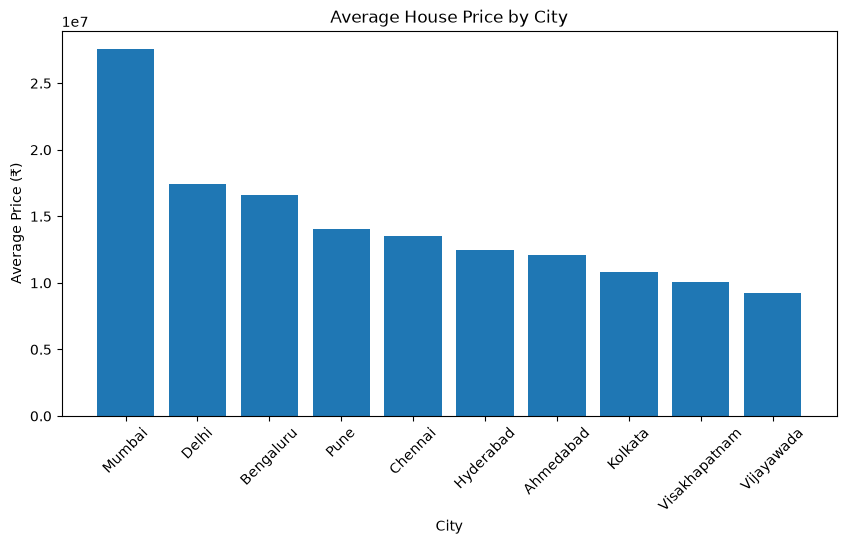

In [338]:
city_price = df.groupby("City")["Price_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_price.index, city_price.values)

plt.title("Average House Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (₹)")
plt.xticks(rotation=45)

plt.show()

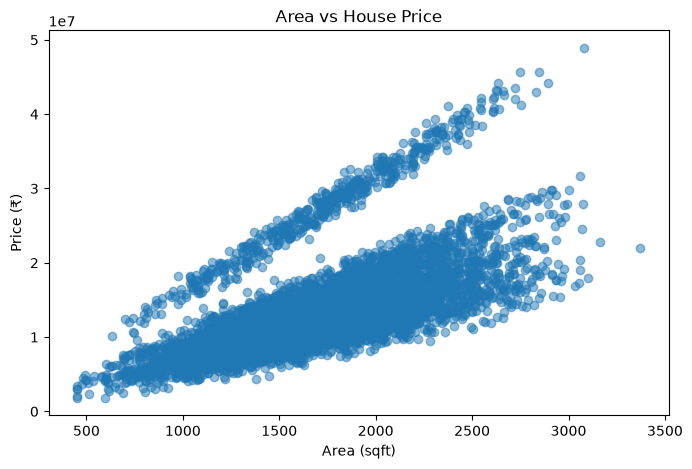

In [339]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area_sqft"],
    df["Price_INR"],
    alpha=0.5
)

plt.title("Area vs House Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (₹)")

plt.show()

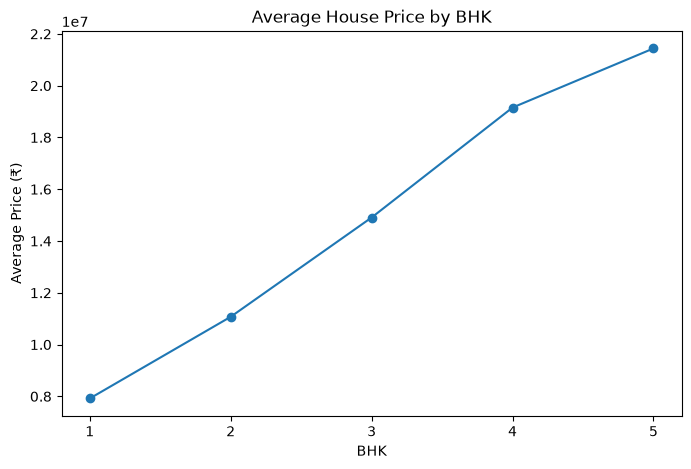

In [340]:
bhk_price = df.groupby("BHK")["Price_INR"].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    bhk_price.index,
    bhk_price.values,
    marker="o"
)

plt.title("Average House Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price (₹)")

plt.xticks(bhk_price.index)

plt.show()

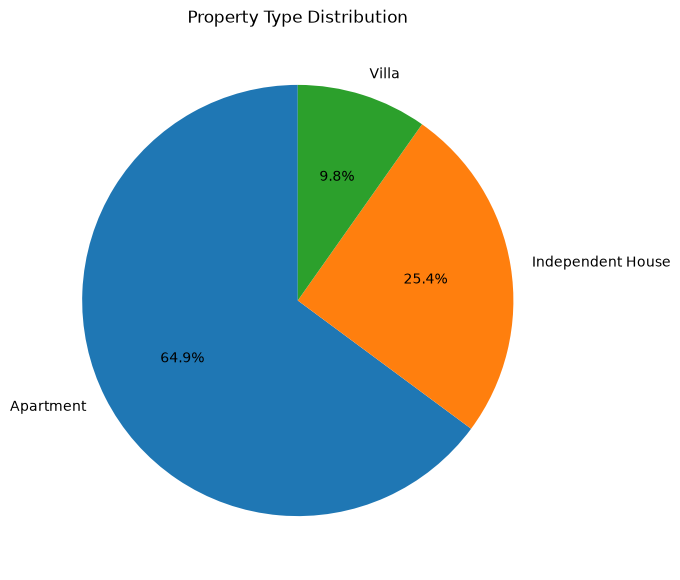

In [341]:
property_count = df["Property_Type"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    property_count.values,
    labels=property_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Property Type Distribution")

plt.show()

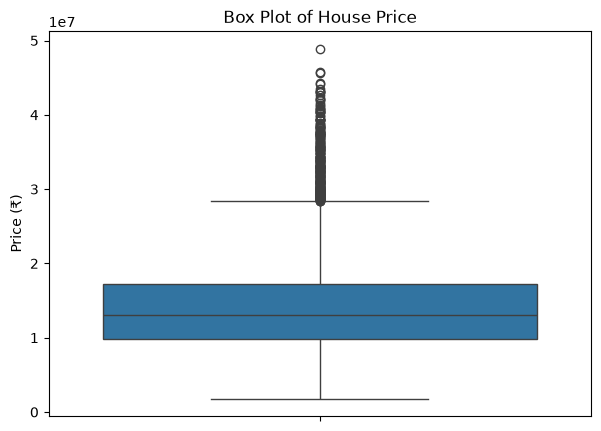

In [342]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.boxplot(y=df["Price_INR"])

plt.title("Box Plot of House Price")
plt.ylabel("Price (₹)")

plt.show()

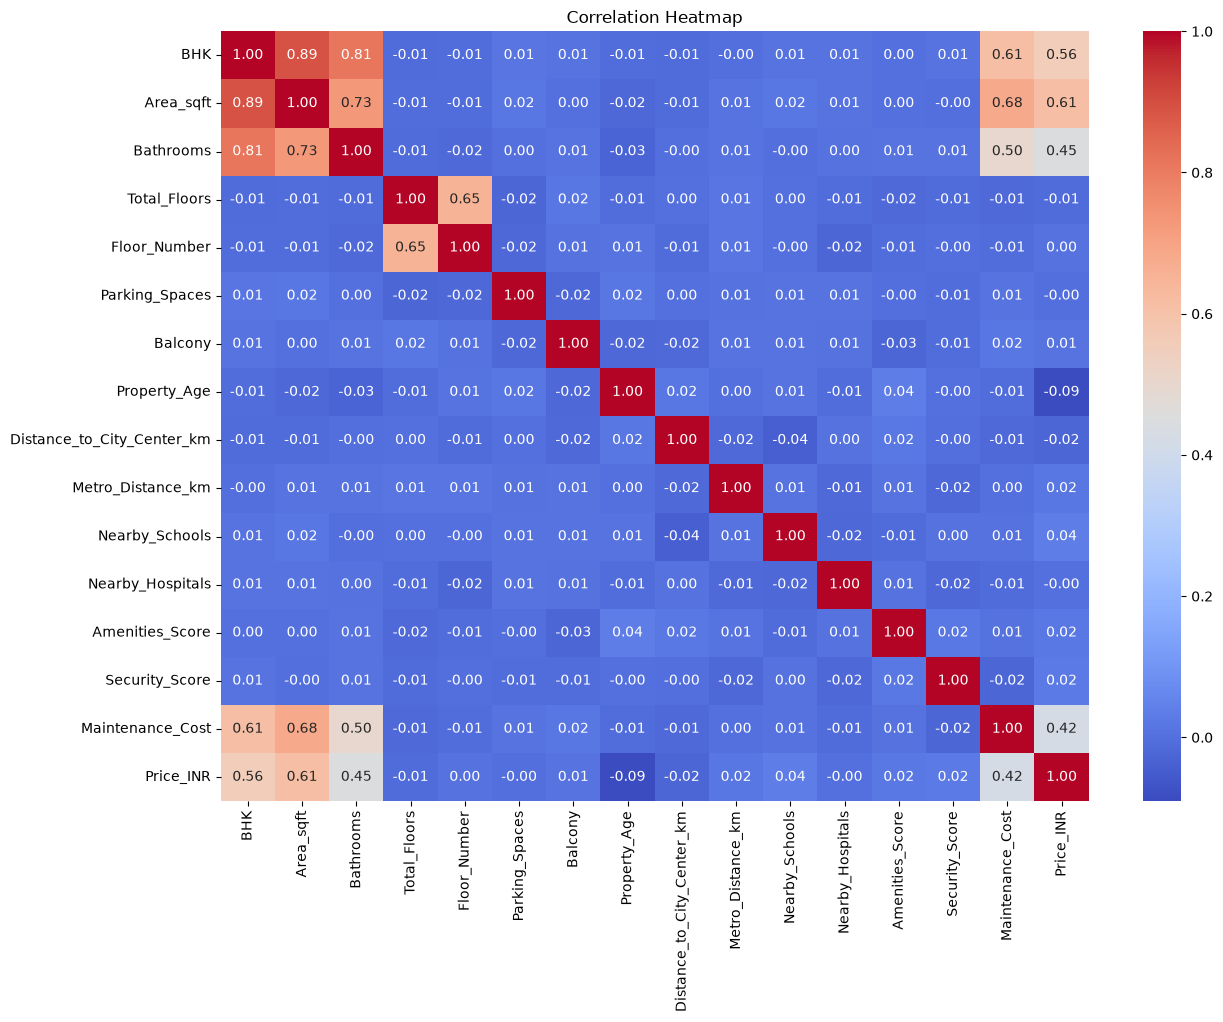

In [343]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Removing Outliers

In [344]:
Q1 = df["Area_sqft"].quantile(0.25)
Q3 = df["Area_sqft"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df["Area_sqft"] >= lower_limit) &
    (df["Area_sqft"] <= upper_limit)
]

print(df.shape)

(5000, 20)


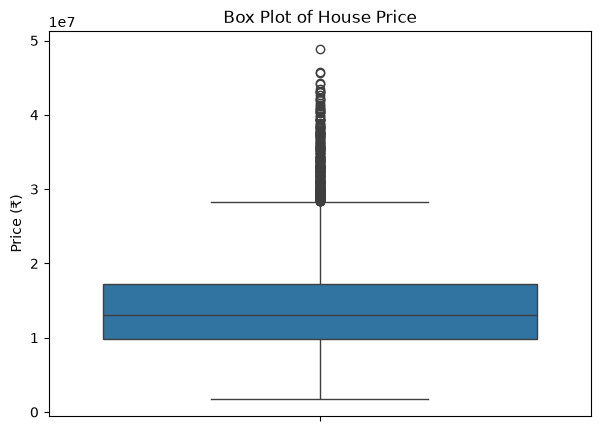

In [345]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.boxplot(y=df["Price_INR"])

plt.title("Box Plot of House Price")
plt.ylabel("Price (₹)")

plt.show()

## Feature Engineering

In [346]:
df["Bath_BHK_Ratio"] = (
    df["Bathrooms"] / df["BHK"]
)

In [347]:
df["Total_Facilities"] = (
    df["Parking_Spaces"]
    + df["Balcony"]
    + df["Nearby_Schools"]
    + df["Nearby_Hospitals"]
)

In [348]:
df["Location_Score"] = (
    df["Nearby_Schools"]
    + df["Nearby_Hospitals"]
    - df["Distance_to_City_Center_km"]
    - df["Metro_Distance_km"]
)

## Check For Invalid House Prices

In [349]:
print("Invalid prices:", (df["Price_INR"] <= 0).sum())
df = df[df["Price_INR"] > 0]

Invalid prices: 0


## Separating Features and Target

In [350]:
X = df.drop(columns=["Price_INR"])
y = df["Price_INR"]


### Handling Categorical Data

In [351]:
print(X.dtypes)

City                              str
Locality                          str
BHK                             int64
Area_sqft                       int64
Bathrooms                     float64
Total_Floors                    int64
Floor_Number                    int64
Parking_Spaces                float64
Balcony                       float64
Property_Age                    int64
Furnishing                        str
Property_Type                     str
Distance_to_City_Center_km    float64
Metro_Distance_km             float64
Nearby_Schools                float64
Nearby_Hospitals                int64
Amenities_Score               float64
Security_Score                  int64
Maintenance_Cost                int64
Bath_BHK_Ratio                float64
Total_Facilities              float64
Location_Score                float64
dtype: object


In [352]:
X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [353]:
X.head()

,BHK,Area_sqft,Bathrooms,Total_Floors,Floor_Number,Parking_Spaces,Balcony,Property_Age,Distance_to_City_Center_km,Metro_Distance_km,...,Locality_Vastrapur,Locality_Velachery,Locality_Viman Nagar,Locality_Wakad,Locality_Whitefield,Locality_Yelahanka,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Property_Type_Independent House,Property_Type_Villa
0,2,1278,2.00,15,14,0.00,1.00,27,6.80,4.80,...,0,0,0,0,0,0,1,0,0,0
1,4,2319,3.00,15,9,2.00,1.00,27,2.70,10.80,...,0,0,0,0,0,0,1,0,0,1
2,2,1173,1.00,3,2,1.00,2.00,29,4.10,1.20,...,0,0,1,0,0,0,0,0,0,0
3,4,2148,4.00,6,3,0.00,1.00,28,4.30,1.70,...,0,0,0,0,0,0,0,1,0,0
4,2,1341,1.00,2,1,1.00,3.00,26,1.50,2.30,...,0,0,0,0,0,0,1,0,0,0


In [354]:
print("Shape after encoding:", X.shape)

Shape after encoding: (5000, 90)


## Train-Test-Split

In [355]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (4000, 90)
X_test : (1000, 90)
y_train: (4000,)
y_test : (1000,)


# Linear Regression

### Create model

In [356]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Train the model

In [357]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [358]:
pd.options.display.float_format = '{:,.2f}'.format

### Prediction

In [359]:
predictions = model.predict(X_test)

predictions_df = pd.DataFrame(predictions, columns=["Predicted Price"])
print(predictions_df.head(10))

   Predicted Price
0    11,625,339.54
1    30,437,017.76
2    17,282,656.22
3    12,145,429.63
4    11,210,870.81
5    15,333,940.60
6    14,681,573.13
7    15,364,806.35
8    18,181,370.39
9    12,852,901.45


In [360]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)


,Actual Price,Predicted Price
0,13206000,"11,625,339.54"
1,34716000,"30,437,017.76"
2,16597000,"17,282,656.22"
3,12594000,"12,145,429.63"
4,11572000,"11,210,870.81"
5,16216000,"15,333,940.60"
6,14329000,"14,681,573.13"
7,13312000,"15,364,806.35"
8,18655000,"18,181,370.39"
9,11937000,"12,852,901.45"


### Model Evaluation

In [361]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [362]:
lr_mae = mean_absolute_error(y_test, predictions)
lr_mse = mean_squared_error(y_test, predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", lr_mae)
print("Mean Squared Error (MSE):", lr_mse)
print("Root Mean Squared Error (RMSE):",lr_rmse)
print("R² Score:", lr_r2)

Mean Absolute Error (MAE): 1053715.1692904588
Mean Squared Error (MSE): 2312230937571.3813
Root Mean Squared Error (RMSE): 1520602.1628195131
R² Score: 0.9451567826141481


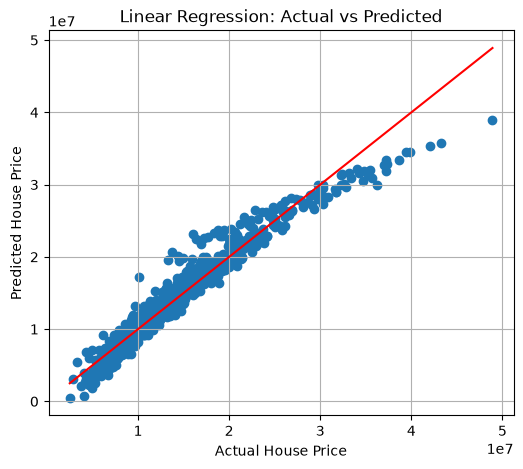

In [363]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

In [364]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.head(10)

,Feature,Coefficient
0,BHK,"291,154.52"
1,Area_sqft,"7,927.29"
2,Bathrooms,"-79,247.23"
3,Total_Floors,"-5,503.80"
4,Floor_Number,"22,300.05"
5,Parking_Spaces,"2,025.85"
6,Balcony,"29,493.99"
7,Property_Age,"-40,965.84"
8,Distance_to_City_Center_km,"-17,239.89"
9,Metro_Distance_km,"-17,871.27"


# Decision Tree 

In [365]:
from sklearn.tree import DecisionTreeRegressor

### Create Model

In [366]:
dt_model = DecisionTreeRegressor(random_state=42)

### Train the model

In [367]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### Predict

In [368]:
dt_predictions = dt_model.predict(X_test)

### Evaluate

In [369]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE : 1139923.0
MSE : 2086263131000.0
RMSE: 1444390.2280893484
R² Score: 0.9505164555328987


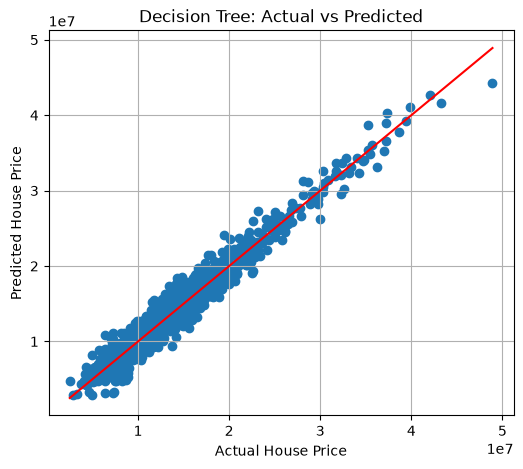

In [370]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, dt_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Random Forest

In [371]:
from sklearn.ensemble import RandomForestRegressor

### Create Model

In [372]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### Train the model

In [373]:
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Predict

In [374]:
rf_predictions = rf_model.predict(X_test)

### Evaluate

In [375]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 811828.45
MSE : 1024361191729.7
RMSE: 1012107.3024782006
R² Score: 0.9757034374867982


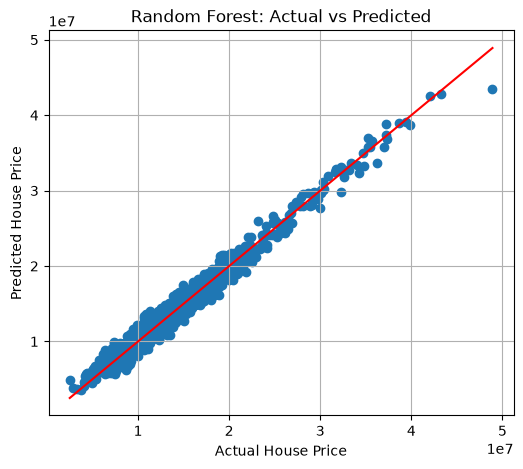

In [376]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, rf_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

### Feature Importance

In [377]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
23,City_Mumbai,0.43
1,Area_sqft,0.41
20,City_Delhi,0.05
18,City_Bengaluru,0.04
25,City_Vijayawada,0.01
24,City_Pune,0.01
26,City_Visakhapatnam,0.01
7,Property_Age,0.01
19,City_Chennai,0.01
22,City_Kolkata,0.00


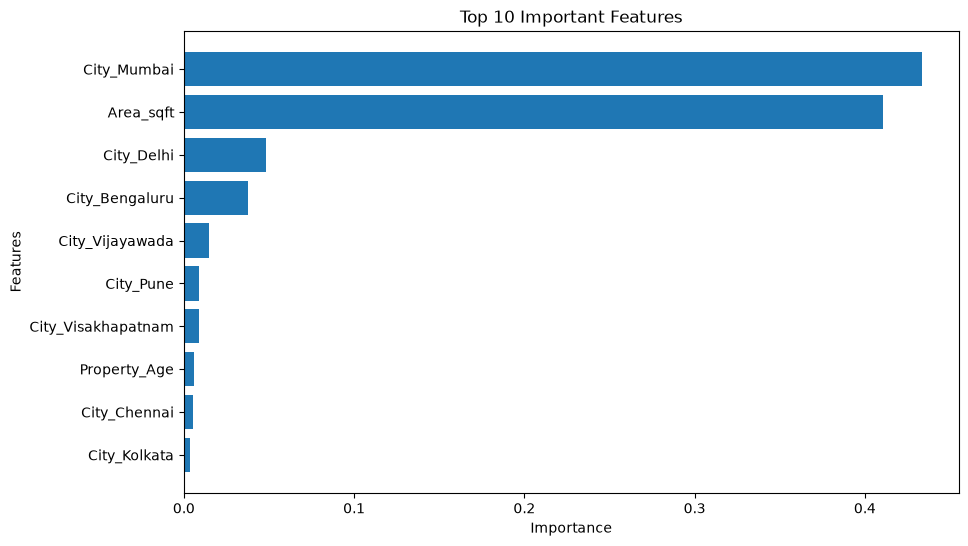

In [378]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

# KNN

In [379]:
from sklearn.neighbors import KNeighborsRegressor

### Create Model

In [380]:
knn_model = KNeighborsRegressor(n_neighbors=5)

### Train the model

In [381]:
knn_model.fit(X_train, y_train)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### Predict

In [382]:
knn_predictions = knn_model.predict(X_test)

### Evaluate

In [383]:
knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Results")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Results
MAE : 4009238.4
MSE : 31923228153600.0
RMSE: 5650064.4380042255
R² Score: 0.2428210725677219


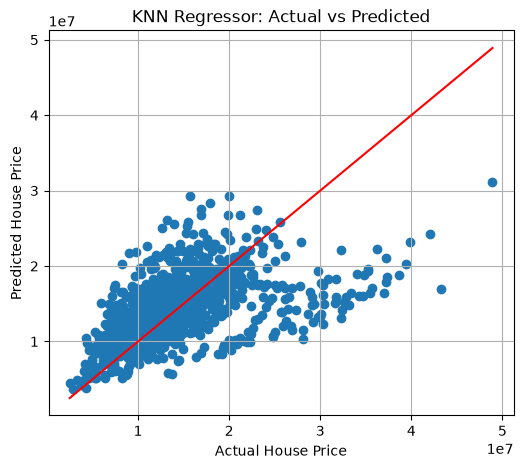

In [384]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, knn_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("KNN Regressor: Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Support Vector Regressor

In [385]:
from sklearn.svm import SVR

### Create Model

In [386]:
svr_model = SVR(kernel="rbf")

### Train The Model

In [387]:
svr_model.fit(X_train, y_train)

print("SVR Model trained successfully!")

SVR Model trained successfully!


### Predict

In [388]:
svr_predictions = svr_model.predict(X_test)

### Evaluate

In [389]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("SVR Results")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

SVR Results
MAE : 4708038.657102922
MSE : 43375812867115.95
RMSE: 6586031.647898145
R² Score: -0.0288198707599161


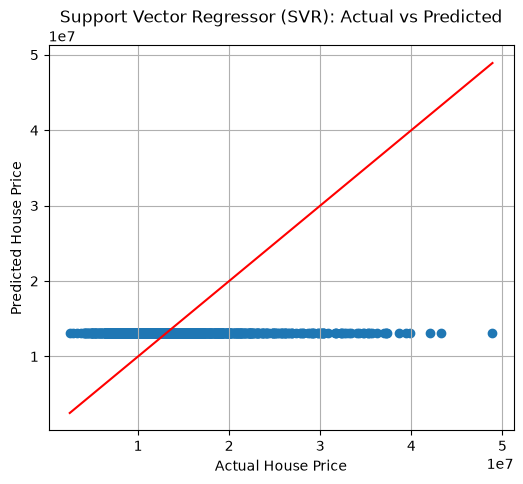

In [390]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, svr_predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title("Support Vector Regressor (SVR): Actual vs Predicted")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.grid(True)

plt.show()

# Comparison

In [391]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE": [lr_mae, dt_mae, rf_mae, knn_mae, svr_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, knn_rmse, svr_rmse],
    "R² Score": [lr_r2, dt_r2, rf_r2, knn_r2, svr_r2]
})

display(comparison)

,Algorithm,MAE,RMSE,R² Score
0,Linear Regression,"1,053,715.17","1,520,602.16",0.95
1,Decision Tree,"1,139,923.00","1,444,390.23",0.95
2,Random Forest,"811,828.45","1,012,107.30",0.98
3,KNN,"4,009,238.40","5,650,064.44",0.24
4,SVR,"4,708,038.66","6,586,031.65",-0.03


# Best Model Selection

In [392]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Algorithm    Random Forest
MAE             811,828.45
RMSE          1,012,107.30
R² Score              0.98
Name: 2, dtype: object


# Cross Validation

In [393]:
from sklearn.model_selection import cross_val_score

rf_cv_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_cv_scores = cross_val_score(
    rf_cv_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest Cross Validation R² Scores:")
print(rf_cv_scores)

print("\nMean Cross Validation R²:")
print(round(rf_cv_scores.mean(), 4))

print("\nStandard Deviation:")
print(round(rf_cv_scores.std(), 4))

Random Forest Cross Validation R² Scores:
[0.97657954 0.97644377 0.97662088 0.97673736 0.97780323]

Mean Cross Validation R²:
0.9768

Standard Deviation:
0.0005


# Hyperparameter Tuning

### Decision Tree Hyperparameter Tuning

In [394]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Decision Tree Model

dt_model = DecisionTreeRegressor(random_state=42)

# Parameters to Test

param_grid = {
    "max_depth": [5, 10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt", "log2"]
}

# Grid Search with 5-Fold Cross Validation

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Train Grid Search

grid_search.fit(X_train, y_train)

# Display Best Parameters

print("Best Parameters")
print(grid_search.best_params_)

# Display Best Cross Validation Score

print("\nBest Cross Validation Score")
print(round(grid_search.best_score_, 4))

# Best Model

best_dt = grid_search.best_estimator_

# Prediction using Tuned Model

opt_dt_prediction = best_dt.predict(X_test)

# Evaluation Metrics

opt_dt_mae = mean_absolute_error(y_test, opt_dt_prediction)

opt_dt_rmse = np.sqrt(
    mean_squared_error(y_test, opt_dt_prediction)
)

opt_dt_r2 = r2_score(
    y_test,
    opt_dt_prediction
)

print("\nOptimized Decision Tree Performance")
print(f"MAE      : {opt_dt_mae:,.2f}")
print(f"RMSE     : {opt_dt_rmse:,.2f}")
print(f"R² Score : {opt_dt_r2:.4f}")

Best Parameters
{'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}

Best Cross Validation Score
0.9602

Optimized Decision Tree Performance
MAE      : 1,044,173.92
RMSE     : 1,315,462.25
R² Score : 0.9590


## Comparison Table after  model tuning

In [395]:
import pandas as pd

comparison_after_tuning = pd.DataFrame({

    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Optimized Decision Tree",
        "KNN",
        "SVR"
    ],

    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        opt_dt_mae,
        knn_mae,
        svr_mae
    ],

    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        opt_dt_rmse,
        knn_rmse,
        svr_rmse
    ],

    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        opt_dt_r2,
        knn_r2,
        svr_r2
    ]
})

comparison_after_tuning = comparison_after_tuning.sort_values(
    by=["R² Score", "RMSE", "MAE"],
    ascending=[False, True, True]
)

comparison_after_tuning = comparison_after_tuning.round(2)

display(comparison_after_tuning)

,Algorithm,MAE,RMSE,R² Score
2,Random Forest,"811,828.45","1,012,107.30",0.98
3,Optimized Decision Tree,"1,044,173.92","1,315,462.25",0.96
1,Decision Tree,"1,139,923.00","1,444,390.23",0.95
0,Linear Regression,"1,053,715.17","1,520,602.16",0.95
4,KNN,"4,009,238.40","5,650,064.44",0.24
5,SVR,"4,708,038.66","6,586,031.65",-0.03


# Select Best Model After Tuning

In [396]:
best_model = rf_model

print("Best Model: Random Forest")

Best Model: Random Forest


# Checking OverFitting

In [397]:
train_prediction = rf_model.predict(X_train)
test_prediction = rf_model.predict(X_test)

train_r2 = r2_score(y_train, train_prediction)
test_r2 = r2_score(y_test, test_prediction)

print("Random Forest Training R²:", train_r2)
print("Random Forest Testing R² :", test_r2)
print("R² Gap                  :", train_r2 - test_r2)

Random Forest Training R²: 0.9967804819317567
Random Forest Testing R² : 0.9757034374867982
R² Gap                  : 0.021077044444958504


## Save Best Model

In [398]:
import joblib

joblib.dump(best_model, "Best_House_Price_Model.pkl")

joblib.dump(X.columns.tolist(), "model_columns.pkl")

print("Best model saved successfully!")
print("Model columns saved successfully!")

Best model saved successfully!
Model columns saved successfully!


In [399]:
loaded_model = joblib.load("Best_House_Price_Model.pkl")
loaded_columns = joblib.load("model_columns.pkl")

print("Model loaded successfully!")
print("Columns loaded successfully!")

Model loaded successfully!
Columns loaded successfully!


## Predict House Price for New Data

In [400]:
new_house = X_test.iloc[[10]]

predicted_price = loaded_model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))
print("Actual House Price: ₹{:,.2f}".format(y_test.iloc[10]))

Predicted House Price: ₹21,973,900.00
Actual House Price: ₹22,272,000.00


In [401]:
new_house = X_test.iloc[[5]]

predicted_price = loaded_model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))
print("Actual House Price: ₹{:,.2f}".format(y_test.iloc[5]))

Predicted House Price: ₹15,146,690.00
Actual House Price: ₹16,216,000.00
